In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
bridge = pd.read_csv("BridgeLevellogger.6.23.26.csv")
bridge["DateTime"] = pd.to_datetime(bridge["DateTime"])
bridge

,DateTime,ms,LEVEL,TEMPERATURE
0,2026-02-03 10:40:00,0,0.5549,-1.674
1,2026-02-03 10:55:00,0,0.5593,-1.682
2,2026-02-03 11:10:00,0,0.5637,-1.687
3,2026-02-03 11:25:00,0,0.5686,-1.689
4,2026-02-03 11:40:00,0,0.5736,-1.684
...,...,...,...,...
13431,2026-06-23 08:25:00,0,0.1939,13.771
13432,2026-06-23 08:40:00,0,0.1964,13.770
13433,2026-06-23 08:55:00,0,0.1983,13.782
13434,2026-06-23 09:10:00,0,0.1990,13.817


In [3]:
bridge.set_index(bridge["DateTime"], inplace=True)
bridge

,DateTime,ms,LEVEL,TEMPERATURE
DateTime,,,,
2026-02-03 10:40:00,2026-02-03 10:40:00,0,0.5549,-1.674
2026-02-03 10:55:00,2026-02-03 10:55:00,0,0.5593,-1.682
2026-02-03 11:10:00,2026-02-03 11:10:00,0,0.5637,-1.687
2026-02-03 11:25:00,2026-02-03 11:25:00,0,0.5686,-1.689
2026-02-03 11:40:00,2026-02-03 11:40:00,0,0.5736,-1.684
...,...,...,...,...
2026-06-23 08:25:00,2026-06-23 08:25:00,0,0.1939,13.771
2026-06-23 08:40:00,2026-06-23 08:40:00,0,0.1964,13.770
2026-06-23 08:55:00,2026-06-23 08:55:00,0,0.1983,13.782


In [4]:
bridge = bridge.resample('D').mean()
bridge

,DateTime,ms,LEVEL,TEMPERATURE
DateTime,,,,
2026-02-03,2026-02-03 17:17:30,0.0,0.602717,-1.425111
2026-02-04,2026-02-04 12:02:30,0.0,0.633275,-0.831542
2026-02-05,2026-02-05 12:02:30,0.0,0.759666,-0.065760
2026-02-06,2026-02-06 12:02:30,0.0,0.236541,0.713406
2026-02-07,2026-02-07 12:02:30,0.0,0.247540,0.805469
...,...,...,...,...
2026-06-19,2026-06-19 12:02:30,0.0,0.204447,15.547490
2026-06-20,2026-06-20 12:02:30,0.0,0.199414,15.559042
2026-06-21,2026-06-21 12:02:30,0.0,0.196324,15.012323


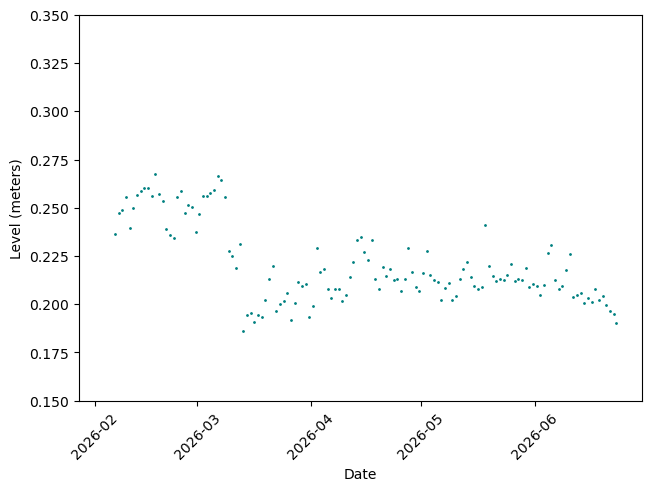

In [5]:
fig, ax = plt.subplots(layout = 'constrained')
ax.scatter(bridge.DateTime, bridge.LEVEL, s = 1, color = "teal", label = "water level at the bridge")
plt.ylim(0.15, 0.35)

# ax.locator_params(axis = "x", nbins=4)
plt.xticks(rotation = 45)
plt.xlabel("Date")
plt.ylabel("Level (meters)")

plt.show()

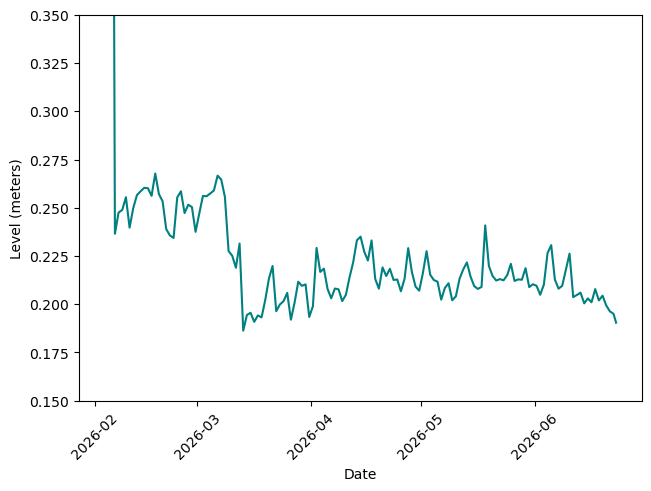

In [8]:
fig, ax = plt.subplots(layout = 'constrained')
ax.plot(bridge.DateTime, bridge.LEVEL, color = "teal", label = "water level at the bridge")
plt.ylim(0.15, 0.35)

plt.xticks(rotation = 45)
plt.xlabel("Date")
plt.ylabel("Level (meters)")

plt.show()

In [ ]:
#adding precipitation data

In [9]:
precip = pd.read_csv("NOAAFaribaultPrecipitation.csv")
precip["Date"] = pd.to_datetime(precip["Date"])
precip = precip[precip["PrecipitationCM"] != 0]
precip

,Date,PrecipitationIN,PrecipitationCM
24,2024-10-25,0.22,0.5588
30,2024-10-31,0.79,2.0066
31,2024-11-01,0.27,0.6858
34,2024-11-04,0.50,1.2700
35,2024-11-05,0.10,0.2540
...,...,...,...
620,2026-06-13,0.29,0.7366
625,2026-06-18,0.21,0.5334
631,2026-06-24,1.83,4.6482
637,2026-06-30,0.14,0.3556


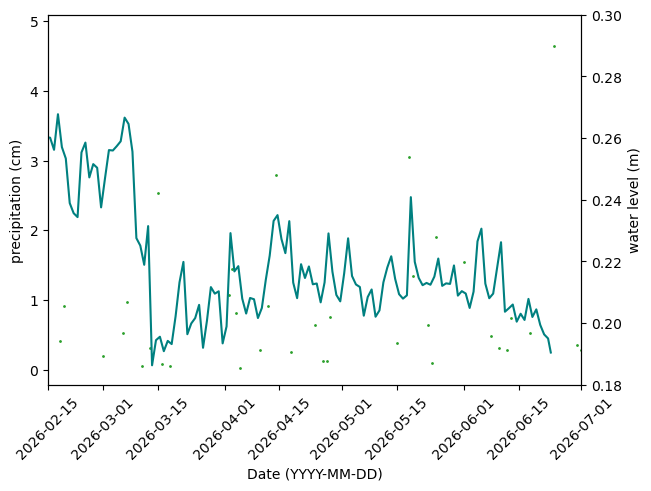

In [35]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('Date (YYYY-MM-DD)')
ax1.set_ylabel('precipitation (cm)')
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, color = "tab:green", s = 1, label = "precipitation (cm)")

ax1.tick_params(axis='x', rotation=45)


ax2 = ax1.twinx() 
ax2.set_ylabel('water level (m)') 
ax2.plot(bridge.DateTime, bridge.LEVEL, color = "teal", label = "daily average water level at the bridge")
ax2.set_ylim(0.18, 0.3)

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.xlim(pd.to_datetime("2026-02-15"), pd.to_datetime("2026-07"))
# leg = rain + C5 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)


plt.show();